# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc227ea"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.6 0.6096666666666667 0.6193333333333333 ... 0.744 0.743 0.742] [0.6 0.6096666666666667 0.621090909090909 ... 0.744 0.743 0.742] [0.6 0.6105454545454545 0.6264615384615385 ... 0.76 0.743 0.742] [0.6 0.624125 0.64825 ... 0.742 0.742 0.742] [0.6 0.6096666666666667 0.6265624999999999 ... 0.743 0.743 0.742] [0.6 0.6096666666666667 0.6193333333333333 ... 0.744 0.743 0.742]] [[0.59 0.6 0.61 ... 0.7593333333333334 0.7636666666666667 0.768] [0.59 0.6 0.6147272727272727 ... 0.7593333333333333 0.7636666666666667 0.768] [0.59 0.6023636363636364 0.6243076923076923 ... 0.759 0.7636666666666667 0.768] [0.59 0.613375 0.63675 ... 0.755 0.7615000000000001 0.768] [0.59 0.6 0.6166874999999999 ... 0.7571666666666667 0.7636666666666667 0.768] [0.59 0.6 0.61 ... 0.7593333333333333 0.7636666666666667 0.768]] [[0.61 0.616 0.622 ... 0.7653333333333333 0.7706666666666667 0.776] [0.61 0.616 0.6303809523809523 ... 0.7653333333333333 0.7706666666666666 0.776] [0.61 0.6201904761904762 0.6429523809523809 ... 0.753 0.7706666666666666 0.776] [0.61 0.63225 0.6545000000000001 ... 0.747 0.7615000000000001 0.776] [0.61 0.616 0.630125 ... 0.7561666666666667 0.7706666666666667 0.776] [0.61 0.616 0.622 ... 0.7653333333333334 0.7706666666666667 0.776]] ... [[2.31 2.3033333333333332 2.296666666666667 ... 2.530833333333333 2.5149999999999997 2.53] [2.31 2.3033333333333332 2.3027272727272727 ... 2.585 2.5575 2.53] [2.31 2.3063636363636366 2.326517857142857 ... 2.5149999999999997 2.5216666666666665 2.53] [2.31 2.3285714285714287 2.3471428571428574 ... 2.5066666666666664 2.5199999999999996 2.53] [2.31 2.3033333333333332 2.309285714285714 ... 2.498333333333333 2.518333333333333 2.53] [2.31 2.3033333333333337 2.296666666666667 ... 2.4899999999999998 2.5166666666666666 2.53]] [[2.33 2.319166666666667 2.3083333333333336 ... 2.54375 2.525 2.5375] [2.33 2.319166666666667 2.3375263157894737 ... 2.6366666666666667 2.587083333333333 2.5375] [2.33 2.3337631578947367 2.3813157894736845 ... 2.53 2.5327777777777776 2.5375] [2.33 2.3475 2.365 ... 2.520277777777778 2.5308333333333333 2.5375] [2.33 2.319166666666667 2.3225000000000002 ... 2.5105555555555554 2.528888888888889 2.5375] [2.33 2.319166666666667 2.308333333333333 ... 2.500833333333333 2.526944444444444 2.5375]] [[2.3099999999999996 2.3091666666666666 2.3083333333333336 ... 2.5759999999999996 2.562 2.56] [2.3099999999999996 2.3091666666666666 2.3348684210526316 ... 2.56 2.56 2.56] [2.3099999999999996 2.3224342105263154 2.374671052631579 ... 2.57 2.5646666666666667 2.56] [2.3099999999999996 2.334642857142857 2.359285714285714 ... 2.5585 2.564 2.56] [2.3099999999999996 2.309166666666666 2.321071428571428 ... 2.5469999999999997 2.563333333333333 2.56] [2.3099999999999996 2.3091666666666666 2.308333333333333 ... 2.5355 2.5626666666666664 2.56]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.6 0.6096666666666667 0.6193333333333333 ... 0.744 0.743 0.742] [0.6 0.6096666666666667 0.621090909090909 ... 0.744 0.743 0.742] [0.6 0.6105454545454545 0.6264615384615385 ... 0.76 0.743 0.742] [0.6 0.624125 0.64825 ... 0.742 0.742 0.742] [0.6 0.6096666666666667 0.6265624999999999 ... 0.743 0.743 0.742] [0.6 0.6096666666666667 0.6193333333333333 ... 0.744 0.743 0.742]] [[0.59 0.6 0.61 ... 0.7593333333333334 0.7636666666666667 0.768] [0.59 0.6 0.6147272727272727 ... 0.7593333333333333 0.7636666666666667 0.768] [0.59 0.6023636363636364 0.6243076923076923 ... 0.759 0.7636666666666667 0.768] [0.59 0.613375 0.63675 ... 0.755 0.7615000000000001 0.768] [0.59 0.6 0.6166874999999999 ... 0.7571666666666667 0.7636666666666667 0.768] [0.59 0.6 0.61 ... 0.7593333333333333 0.7636666666666667 0.768]] [[0.61 0.616 0.622 ... 0.7653333333333333 0.7706666666666667 0.776] [0.61 0.616 0.6303809523809523 ... 0.7653333333333333 0.7706666666666666 0.776] [0.61 0.6201904761904762 0.6429523809523809 ... 0.753 0.7706666666666666 0.776] [0.61 0.63225 0.6545000000000001 ... 0.747 0.7615000000000001 0.776] [0.61 0.616 0.630125 ... 0.7561666666666667 0.7706666666666667 0.776] [0.61 0.616 0.622 ... 0.7653333333333334 0.7706666666666667 0.776]] ... [[2.31 2.3033333333333332 2.296666666666667 ... 2.530833333333333 2.5149999999999997 2.53] [2.31 2.3033333333333332 2.3027272727272727 ... 2.585 2.5575 2.53] [2.31 2.3063636363636366 2.326517857142857 ... 2.5149999999999997 2.5216666666666665 2.53] [2.31 2.3285714285714287 2.3471428571428574 ... 2.5066666666666664 2.5199999999999996 2.53] [2.31 2.3033333333333332 2.309285714285714 ... 2.498333333333333 2.518333333333333 2.53] [2.31 2.3033333333333337 2.296666666666667 ... 2.4899999999999998 2.5166666666666666 2.53]] [[2.33 2.319166666666667 2.3083333333333336 ... 2.54375 2.525 2.5375] [2.33 2.319166666666667 2.3375263157894737 ... 2.6366666666666667 2.587083333333333 2.5375] [2.33 2.3337631578947367 2.3813157894736845 ... 2.53 2.5327777777777776 2.5375] [2.33 2.3475 2.365 ... 2.520277777777778 2.5308333333333333 2.5375] [2.33 2.319166666666667 2.3225000000000002 ... 2.5105555555555554 2.528888888888889 2.5375] [2.33 2.319166666666667 2.308333333333333 ... 2.500833333333333 2.526944444444444 2.5375]] [[2.3099999999999996 2.3091666666666666 2.3083333333333336 ... 2.5759999999999996 2.562 2.56] [2.3099999999999996 2.3091666666666666 2.3348684210526316 ... 2.56 2.56 2.56] [2.3099999999999996 2.3224342105263154 2.374671052631579 ... 2.57 2.5646666666666667 2.56] [2.3099999999999996 2.334642857142857 2.359285714285714 ... 2.5585 2.564 2.56] [2.3099999999999996 2.309166666666666 2.321071428571428 ... 2.5469999999999997 2.563333333333333 2.56] [2.3099999999999996 2.3091666666666666 2.308333333333333 ... 2.5355 2.5626666666666664 2.56]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc227ea' (lon: 6, lat: 12, year: 13, month: 12)> Size: 90kB
<Quantity([[[[0.61       0.61666667 0.62       ... 0.6925     0.68666667
    0.6975    ]
   [0.71       0.69       0.70666667 ... 0.75333333 0.755
    0.76333333]
   [0.8        0.80666667 0.80333333 ... 0.8575     0.85
    0.86666667]
   ...
   [1.66666667 1.7        1.725      ... 1.835      1.83333333
    1.83      ]
   [1.83       1.8375     1.88       ... 1.9825     1.995
    1.99      ]
   [2.         2.02       2.02       ... 2.13       2.13666667
    2.155     ]]

  [[0.616      0.60703333 0.6258     ... 0.67196667 0.69010833
    0.68951667]
   [0.69215    0.6998     0.6962     ... 0.75406667 0.7541
    0.74846667]
   [0.7816     0.75843333 0.78816667 ... 0.82525    0.85545
    0.86963333]
...
   [1.95033333 1.95566667 1.97208333 ... 2.07666667 2.09875
    2.108     ]
   [2.14108333 2.16091667 2.15475    ... 2.22986111 2.2655
    2.27766667]
   [2.30441667 2.3045     2.32744444 ... 2.42555556 2.45622222
    2.48894444]]

  [[0.776      0.776      0.769      ... 0.798      0.81825
    0.837     ]
   [0.83925    0.83575    0.8435     ... 0.91116667 0.9195
    0.946     ]
   [0.95225    0.9535     0.96225    ... 1.004      1.026
    1.03216667]
   ...
   [1.9625     1.97525    1.98683333 ... 2.079      2.101
    2.1365    ]
   [2.1495     2.16825    2.168      ... 2.25475    2.28283333
    2.3045    ]
   [2.32675    2.33225    2.3385     ... 2.448      2.48
    2.52525   ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 104B 2011 2012 2013 2014 2015 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.61 0.6166666666666667 0.62 ... 2.13 2.1366666666666667 2.155] [0.616 0.6070333333333333 0.6258 ... 2.1390249999999997 2.1688833333333335 2.15325] [0.622 0.6185 0.634 ... 2.175125 2.19775 2.1912499999999997] ... [0.7653333333333333 0.776 0.7743333333333334 ... 2.4229166666666666 2.4457500000000003 2.47175] [0.7706666666666667 0.7760000000000001 0.7716666666666667 ... 2.3579999999999997 2.39 2.4225000000000003] [0.776 0.776 0.769 ... 2.404 2.436 2.4838750000000003]] [[0.61 0.6166666666666667 0.62 ... 2.13 2.1366666666666667 2.155] [0.616 0.6 0.625 ... 2.13 2.17 2.1399999999999997] [0.6303809523809523 0.6261111111111111 0.6446666666666666 ... 2.177142857142857 2.2073214285714284 2.189404761904762] ... [0.7653333333333333 0.776 0.7743333333333334 ... 2.4 2.435 2.465] [0.7706666666666666 0.776 0.7716666666666667 ... 2.38 2.4135 2.45375] [0.776 0.776 0.769 ... 2.36 2.392 2.4425]] [[0.61 0.6166666666666667 0.62 ... 2.13 2.1366666666666667 2.155] [0.6201904761904762 0.6205757575757576 0.6335454545454545 ... 2.1505 2.1732843137254902 2.1849090909090907] [0.6429523809523809 0.645060606060606 0.6556363636363637 ... 2.1915 2.2131862745098037 2.2597272727272726] ... [0.753 0.756 0.773 ... 2.4785 2.4924999999999997 2.465] [0.7706666666666666 0.776 0.7716666666666667 ... 2.37 2.395 2.425] [0.776 0.776 0.769 ... 2.448 2.48 2.5252499999999998]] [[0.61 0.6166666666666667 0.62 ... 2.13 2.1366666666666667 2.155] [0.63225 0.6379583333333333 0.642375 ... 2.1818125 2.1916458333333333 2.20725] [0.6545000000000001 0.65925 0.66475 ... 2.233625 2.246625 2.2595] ... [0.747 0.756 0.77 ... 2.5853333333333333 2.6093333333333333 2.635666666666667] [0.7615000000000001 0.766 0.7695000000000001 ... 2.5606666666666666 2.5886666666666667 2.6218333333333335] [0.776 0.776 0.769 ... 2.536 2.568 2.608]] [[0.61 0.6166666666666667 0.62 ... 2.13 2.1366666666666667 2.155] [0.616 0.6211 0.6274 ... 2.157075 2.16665 2.17975] [0.630125 0.6374791666666667 0.6426875 ... 2.2010312499999998 2.2085729166666668 2.224875] ... [0.7561666666666667 0.766 0.7721666666666667 ... 2.531194444444444 2.5548055555555553 2.5810277777777775] [0.7706666666666667 0.776 0.7716666666666666 ... 2.4931111111111113 2.522444444444445 2.555388888888889] [0.776 0.776 0.769 ... 2.492 2.524 2.566625]] [[0.61 0.6166666666666667 0.62 ... 2.13 2.1366666666666667 2.155] [0.616 0.6140666666666666 0.6266 ... 2.14805 2.1677666666666666 2.1665] [0.622 0.6255333333333333 0.6348 ... 2.18415 2.1966333333333337 2.2045] ... [0.7653333333333334 0.776 0.7743333333333333 ... 2.4770555555555553 2.500277777777778 2.526388888888889] [0.7706666666666667 0.776 0.7716666666666667 ... 2.4255555555555555 2.4562222222222223 2.488944444444445] [0.776 0.776 0.769 ... 2.448 2.48 2.5252499999999998]]]
Units,ppt


### Longitudinal-mean

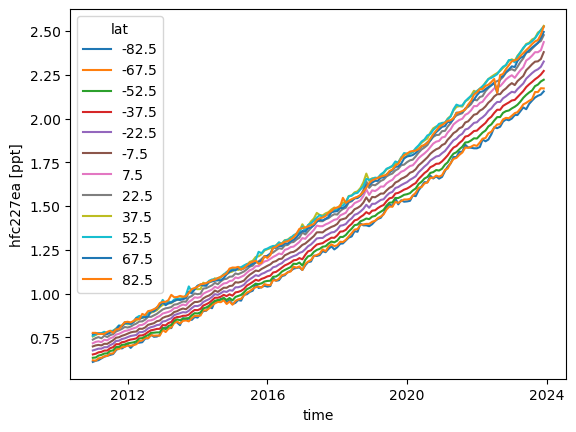

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

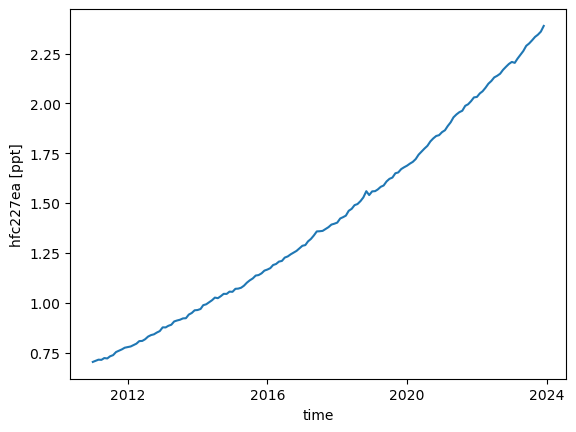

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

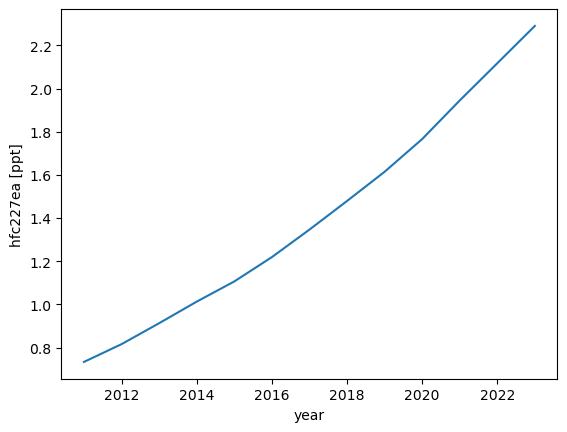

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[0.46618456960137344 -0.4661470352988022 0.6444080785490421 0.18597715935058656 0.12056185139374363 0.2157747361738192 -0.19011359360759642 -0.03382655567986706 0.11596047946550289 -0.0269414365479614 -0.011666775278019738 0.0532870948343689] [0.4476410551690503 -0.188537776898173 -0.15771647611840534 0.12749750359304313 -0.025587085577196 -0.29135495194172956 0.6750918097814332 0.23208868900371038 -0.15532848059423576 0.27628921808806445 -0.05398089320565183 0.15622985705148068] [0.35788335987097625 -0.05586423010823104 -0.26136520323812584 -0.08148000595973245 0.11049691779023608 -0.29926721046989296 -0.20176437154945956 -0.12452748281237433 -0.24688068825411544 -0.6642287118693783 0.26822864220698595 0.24852581269634855] [0.2587621037457653 0.04085623842855369 -0.2495997577989944 -0.18256110086962865 0.09044266338020324 -0.12368599514497813 -0.4362509538693856 -0.14403100069942157 0.051256268540358606 0.34091910422956095 -0.6143710559221655 0.32388514489780157] [0.14561623499553353 0.10184003763253205 -0.14385248797622394 -0.1320242515452212 -0.01693350498818542 0.14210375016163518 -0.15274074805643426 0.05278884236044839 0.34173083956046485 0.4013943482690135 0.6808433536292773 0.3771722397549386] [0.032200079807246415 0.16268314710293585 -0.042034798708687406 -0.06793525119502813 -0.13614121918390998 0.4215133243442121 0.23687996342574785 0.34760059483571953 0.3984029847479767 -0.4336622687073064 -0.2869738095119529 0.40475566973927957] [-0.08628825446200786 0.15760941133354933 0.14261287908000128 0.007294863850914747 -0.024315058018509625 0.44880868496962056 0.03683399806399188 -0.06818272897421848 -0.7486879805859084 0.11919246693019668 0.026984957858545152 0.40475566974559885] [-0.1884515379550183 0.05209104255273387 0.13512573970539057 0.32622037882015686 -0.170574906578336 -0.1856705128116637 0.24940090221245298 -0.7167621983812051 0.22964814504631212 -0.041346252766796 -0.02947815008042222 0.37717223974178243] [-0.31156649729102326 0.0829035037192569 0.14346195624827782 0.5409349401137474 0.21888120932158045 -0.3699302849124256 -0.24335329190253788 0.4829309086732095 -0.020882356679099847 0.017971306363864417 0.0005196387827368219 0.32388514490767645] [-0.31384050512673956 -0.17858104701043032 0.3366437380553511 -0.6537902761636919 0.3932482750356838 -0.260715175563264 0.2075912261788036 0.022015340142563723 0.02853265593080663 -0.008222746695604759 9.404443060574245e-05 0.24852581269316437] [-0.23165698719625613 -0.534812864396092 -0.03668032250290464 -0.1440663370163302 -0.7329222999153321 -0.12993666582010233 -0.1706492269839111 0.1526374608843769 -0.0852333906046705 0.004701627866367765 0.006090357401756422 0.15622985705196157] [-0.2698444450538457 -0.5942979216395113 -0.48263680565542905 0.19965805720020333 0.4197430327726886 0.3289686573524647 0.051464612592764344 -0.09860872296113961 0.03946095680781218 -0.0018384860633075353 -0.003923077408987936 0.053287094834543344]]
Units,ppt
Magnitude,[[-0.18084006331109675 -0.011691354360068403 -0.003343648475865398 -0.0010033253622685444 -0.00611440391238654 -9.645100550531836e-05 -0.0005781179294975694 -3.957734726921544e-06 0.0002891520589302769 -2.215972532816753e-05 -3.4943893274915827e-06 -8.487750684147699e-17] [-0.1890997397847246 -0.019495753751897844 -0.0058626251926566205 -0.0017544216619629841 -0.0016960043911816449 0.0016387643070552749 0.0003379932028055291 -0.0008779566853854452 -0.0002873568259335629 3.233680313141267e-05 3.361728823881098e-06 8.634088492203084e-17] [-0.19782998570902097 -0.02835383849410377 -0.0019749509906835236 0.0003974625997065099 0.004041479650383701 0.002222463791580276 -0.00013776965554440217 9.263914917578981e-05 0.00034164679568591004 -2.6929012326712692e-05 -3.642591073420542e-06 4.5410201857231785e-17] [-0.20395295696618462 -0.024681004815752066 0.0009260711651758327 2.547814077630866e-05 0.0007987447482993 -0.0014821575245344103 -0.0006430789112702231 0.000738182567763845 -0.00017863530705337677 6.192632047656444e

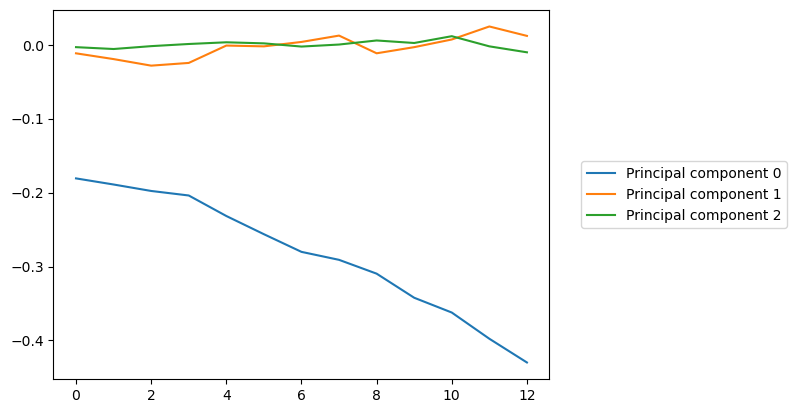

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

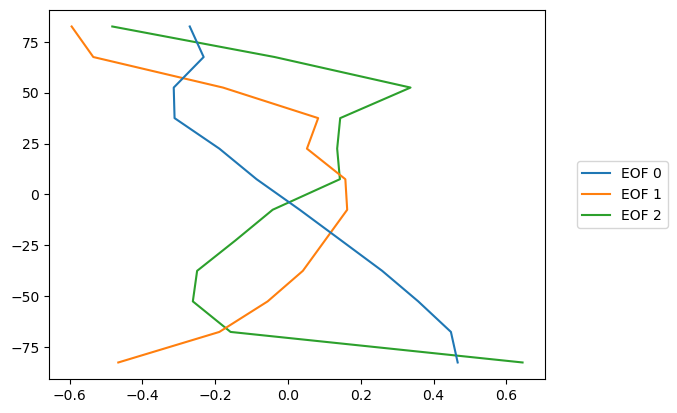

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

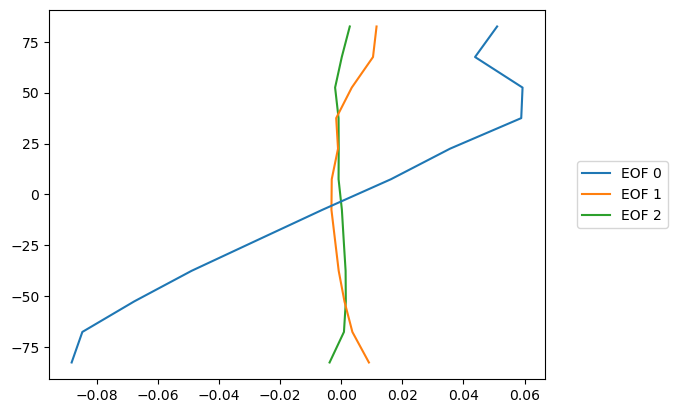

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.46618456960137344] [0.4476410551690503] [0.35788335987097625] [0.2587621037457653] [0.14561623499553353] [0.032200079807246415] [-0.08628825446200786] [-0.1884515379550183] [-0.31156649729102326] [-0.31384050512673956] [-0.23165698719625613] [-0.2698444450538457]]
Units,ppt
Magnitude,[[-0.18084006331109675] [-0.1890997397847246] [-0.19782998570902097] [-0.20395295696618462] [-0.23169896766053077] [-0.25630570079424325] [-0.2801995893492204] [-0.2909912154173923] [-0.30967027520625784] [-0.3422574309875622] [-0.3622519152907002] [-0.39770336416815555] [-0.4297931953470356]]
Units,dimensionless


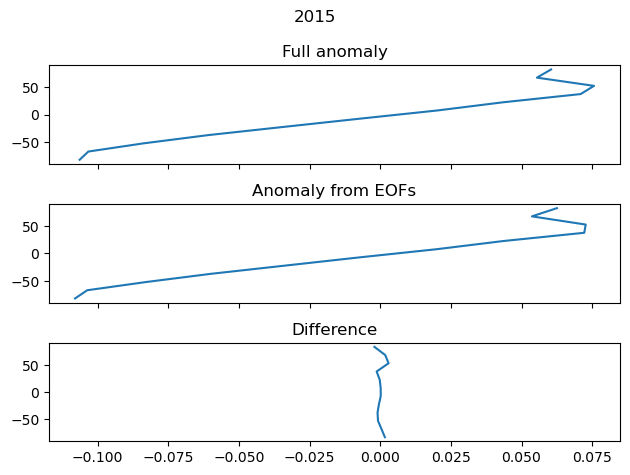

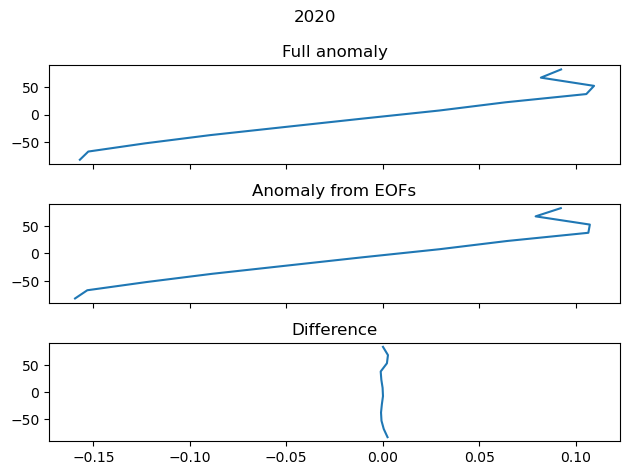

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/156 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:00<00:00, 12318.54it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/156 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/156 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:00<00:00, 18211.23it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/156 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:00<00:00, 19449.24it/s]

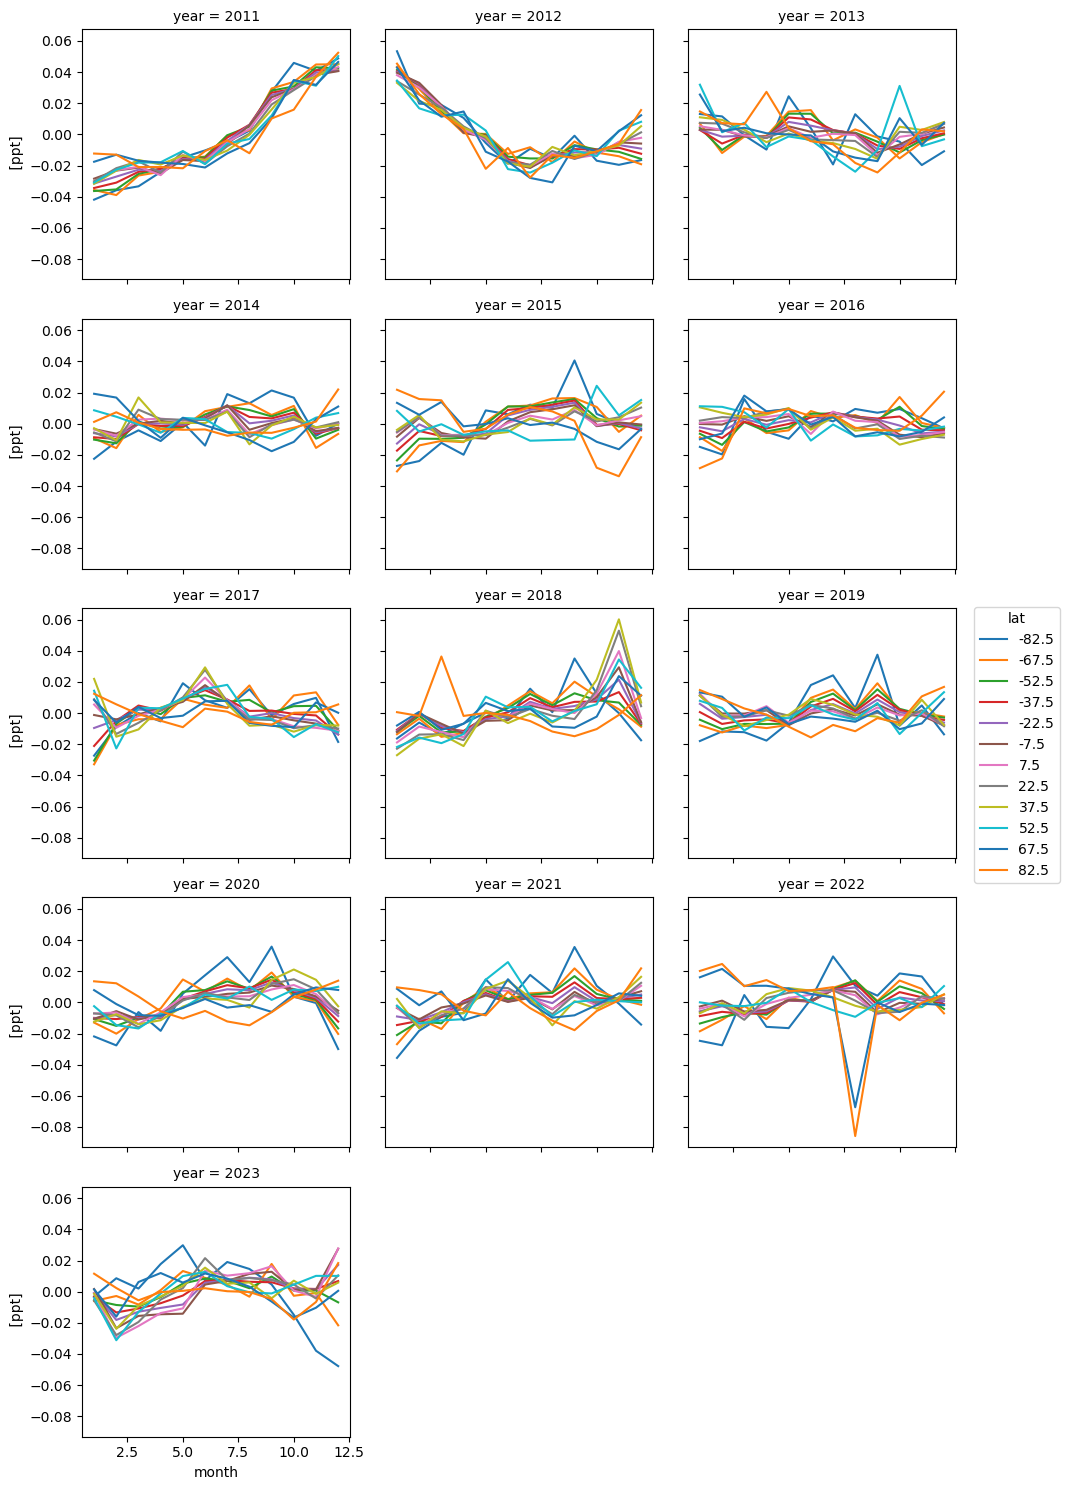

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

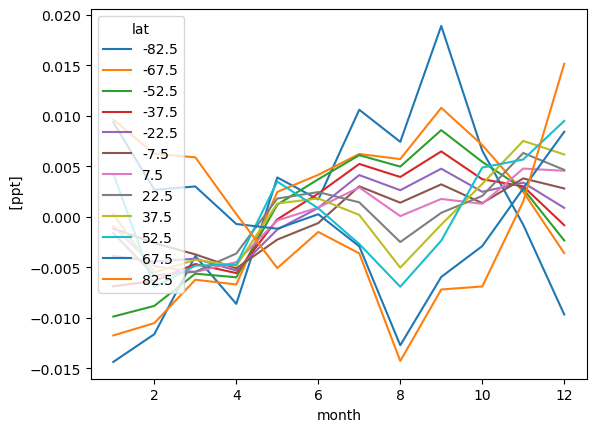

In [22]:
seasonality.plot.line(hue="lat")

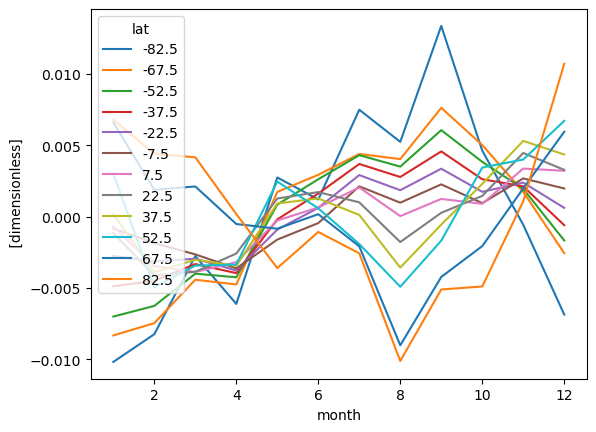

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[0.7334766588629088 0.8157302480732894 0.9127184075051219 1.0127051819267812 1.1062433389647333 1.2188642110688035 1.3463548207250566 1.4789566333967998 1.6142345943936371 1.7658063528501058 1.944674511070201 2.117217280016668 2.290184068444324]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.46618456960137344] [0.4476410551690503] [0.35788335987097625] [0.2587621037457653] [0.14561623499553353] [0.032200079807246415] [-0.08628825446200786] [-0.1884515379550183] [-0.31156649729102326] [-0.31384050512673956] [-0.23165698719625613] [-0.2698444450538457]]
Units,ppt
Magnitude,[[-0.18084006331109675] [-0.1890997397847246] [-0.19782998570902097] [-0.20395295696618462] [-0.23169896766053077] [-0.25630570079424325] [-0.2801995893492204] [-0.2909912154173923] [-0.30967027520625784] [-0.3422574309875622] [-0.3622519152907002] [-0.39770336416815555] [-0.4297931953470356]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.010179059686705197 -0.008235351503961702 -0.0027599823976024486 -0.006111464226980134 0.002750795892834481 0.0012088958360048998 0.007496525246388565 0.005245916231794168 0.01337219396208155 0.004632320697165983 -0.0005650347059663711 -0.006855934975411688] [-0.008322709574006883 -0.007459807436278607 -0.004417422944705718 -0.004750397783240306 0.0017344967487074043 0.00293605356793462 0.004397027548877956 0.0040381590197852285 0.007631377387566164 0.005023591539428842 0.0017442451092911577 -0.00255474422135068] [-0.007000310112340575 -0.006252268893836346 -0.003993673581843081 -0.004247080677984941 0.000845626719550896 0.002625440499822466 0.004314141338351352 0.0035108614579632534 0.006068130664466009 0.0038432310411879267 0.0019518316167035973 -0.0016660490653631905] [-0.00487533710291406 -0.004501856142212715 -0.003318119973288098 -0.003952899464746943 -0.0001859216398930519 0.0016206001335164523 0.0036964344638493046 0.002783037261743054 0.004575782905748445 0.0026260566600879325 0.002129333745364703 -0.0005972188207127768] [-0.002750279360629266 -0.003137013858145118 -0.002944244630229268 -0.0037726515316213963 -0.0009042609038653819 0.0006169250258306702 0.002917999911102134 0.0018566320828359954 0.003364282435346988 0.0017436051339970319 0.0023907756465923985 0.00061812824988903] [-0.0008271837576887999 -0.0018490610370145322 -0.0026425841355180377 -0.003623090747336917 -0.0016048699990965562 -0.0004471337905707532 0.0021289203269192355 0.000983012907198773 0.002266514075748885 0.0009522682930268991 0.0026834535088967916 0.001979658904471566] [-0.0006847857583593289 -0.0034703834842201337 -0.0038756881224496194 -0.003185733014318954 -0.0002647562127763999 0.0006461534059592381 0.002051096053196823 4.26179678254613e-05 0.00124435341012626 0.0009049149099203203 0.0033732847767228478 0.0032188186985690026] [-0.0011528213080774954 -0.004118681662957288 -0.0038581264654420364 -0.0025823353415667916 0.0012743316681748697 0.0017257518501719324 0.0010061203073498451 -0.0017760578933229505 0.0002739228994322423 0.0014564335949452782 0.00446680453663624 0.0032845294504450736] [0.00019114225969937837 -0.0039036481781290476 -0.003016169379139754 -0.0034461438507532695 0.0009279627369249147 0.0012791781208984397 0.00012293110222118346 -0.0035694072520279876 -0.0005539918410260927 0.0022946438166763085 0.005313001245125963 0.004360369223485096] [0.003011792203608777 -0.004941230970335227 -0.0034265979699389 -0.0033549456942646378 0.0024601827966448673 0.000587941977057133 -0.0019161385510520225 -0.004911625932941238 -0.0016772654282678527 0.0034446963098861325 0.004009686373766202 0.006713381753191531] [0.006611550434198532 0.0018888870795882302 0.0021194838270093192 -0.0005129312794553504 -0.0008404076824904528 0.00017361653652147246 -0.0020756828422283237 -0.009011660507690766 -0.0042222379676681784 -0.0020617521252465597 0.001979493022937006 0.005951489734489711] [0.0068005493911614135 0.004406958852376866 0.004164819193345544 0.0001808493120672262 -0.0036014818283043723 -0.0010683370754102758 -0.0025689682508201576 -0.010112510450820887 -0.005102800957526586 -0.004889586233716141 0.0010723707322851167 0.010717999153475828]]
Units,dimensionless
